In [1]:
from __future__ import division
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
import pickle
%matplotlib inline

In [2]:
generation_list = []

for i in range(2002):
    generation_list.append(i)
    
print(len(generation_list))

2002


In [3]:
def get_data1(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    total_var_mean = []
    total_var_std = []
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
        var_mean = []
        var_std = []
       
        fit_mean.extend(list(pd.Series(f.mFit_Mean,dtype=float)))
        fit_std.extend(list(pd.Series(f.mFit_Std,dtype=float)))
    
        var_mean.extend(list(pd.Series(f.varFit_Mean,dtype=float)))
        var_std.extend(list(pd.Series(f.varFit_Std,dtype=float)))
    
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        total_var_mean.append(var_mean)
        total_var_std.append(var_std)  
        
    return total_fit_mean, total_fit_std, total_var_mean, total_var_std

## N =500_Initial fitness =0.5_Dim = 10_Different Ploidy

### Fitness dynamics comparison

#### Amitosis

In [4]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190102_Test of FGM_6_Trial of Moving Optimum\Data\5.1. MO STD = 0.01_Adaptation\Amito")

In [5]:
amito = [ 'Cor_Rv_MoveOpt_SM01_NoPley_GMU001_Dim10_P16_Amito_Fit_N1K_Fit05_SM005_2KG.csv', 'Cor_Rv_MoveOpt_SM01_NoPley_GMU001_Dim10_P128_Amito_Fit_N1K_Fit05_SM005_2KG.csv']

In [6]:
m = get_data1(amito)

amito_fit_mean =m[0]
amito_fit_std = m[1]
amito_var_mean =m[2]
amito_var_std = m[3]

#### Mitosis

In [20]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190102_Test of FGM_6_Trial of Moving Optimum\Data\5.1. MO STD = 0.01_Adaptation\Mito")

In [21]:
mito = ['Cor_Rv_MoveOpt_SM01_NoPley_GMU001_Dim10_P16_Mito_Fit_N1K_Fit05_SM005_2KG.csv', 'Cor_Rv_MoveOpt_SM01_NoPley_GMU001_Dim10_P128_Mito_Fit_N1K_Fit05_SM005_2KG.csv']

In [22]:
s = get_data1(mito)

mito_fit_mean =s[0]
mito_fit_std = s[1]
mito_var_mean =s[2]
mito_var_std = s[3]

#### RM

In [15]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190331_Test of FGM_7_Trial of Incorporating Sex\Data\2. NP_MO All Dim STD = 0.01_D = L =10\RM")

In [18]:
rm = ['DetermMOSM01_NP_GMU001_Dim10_P16_RM_Fit_N500_Fit05_SM005_Cor.csv', 'DetermMOSM01_NP_GMU001_Dim10_P128_RM_Fit_N500_Fit05_SM005_Cor.csv']

In [19]:
n = get_data1(rm)

rm_fit_mean =n[0]
rm_fit_std = n[1]
rm_var_mean =n[2]
rm_var_std = n[3]

#### RME100

In [23]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190331_Test of FGM_7_Trial of Incorporating Sex\Data\2. NP_MO All Dim STD = 0.01_D = L =10\RME100")

In [24]:
rme = ['DetermMOSM01_NP_GMU001_Dim10_P16_RME100_Fit_N500_Fit05_SM005_Cor.csv', 'DetermMOSM01_NP_GMU001_Dim10_P128_RME100_Fit_N500_Fit05_SM005_Cor.csv']

In [25]:
n2 = get_data1(rme)

rme_fit_mean =n2[0]
rme_fit_std = n2[1]
rme_var_mean =n2[2]
rme_var_std = n2[3]

In [26]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 36})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(6)
    ax.spines['bottom'].set_linewidth(6)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=20, width=6, direction='out', pad=50, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=20, width=6, direction='out', pad=50, colors='black')

### Ploidy = 16

(0.2, 1)

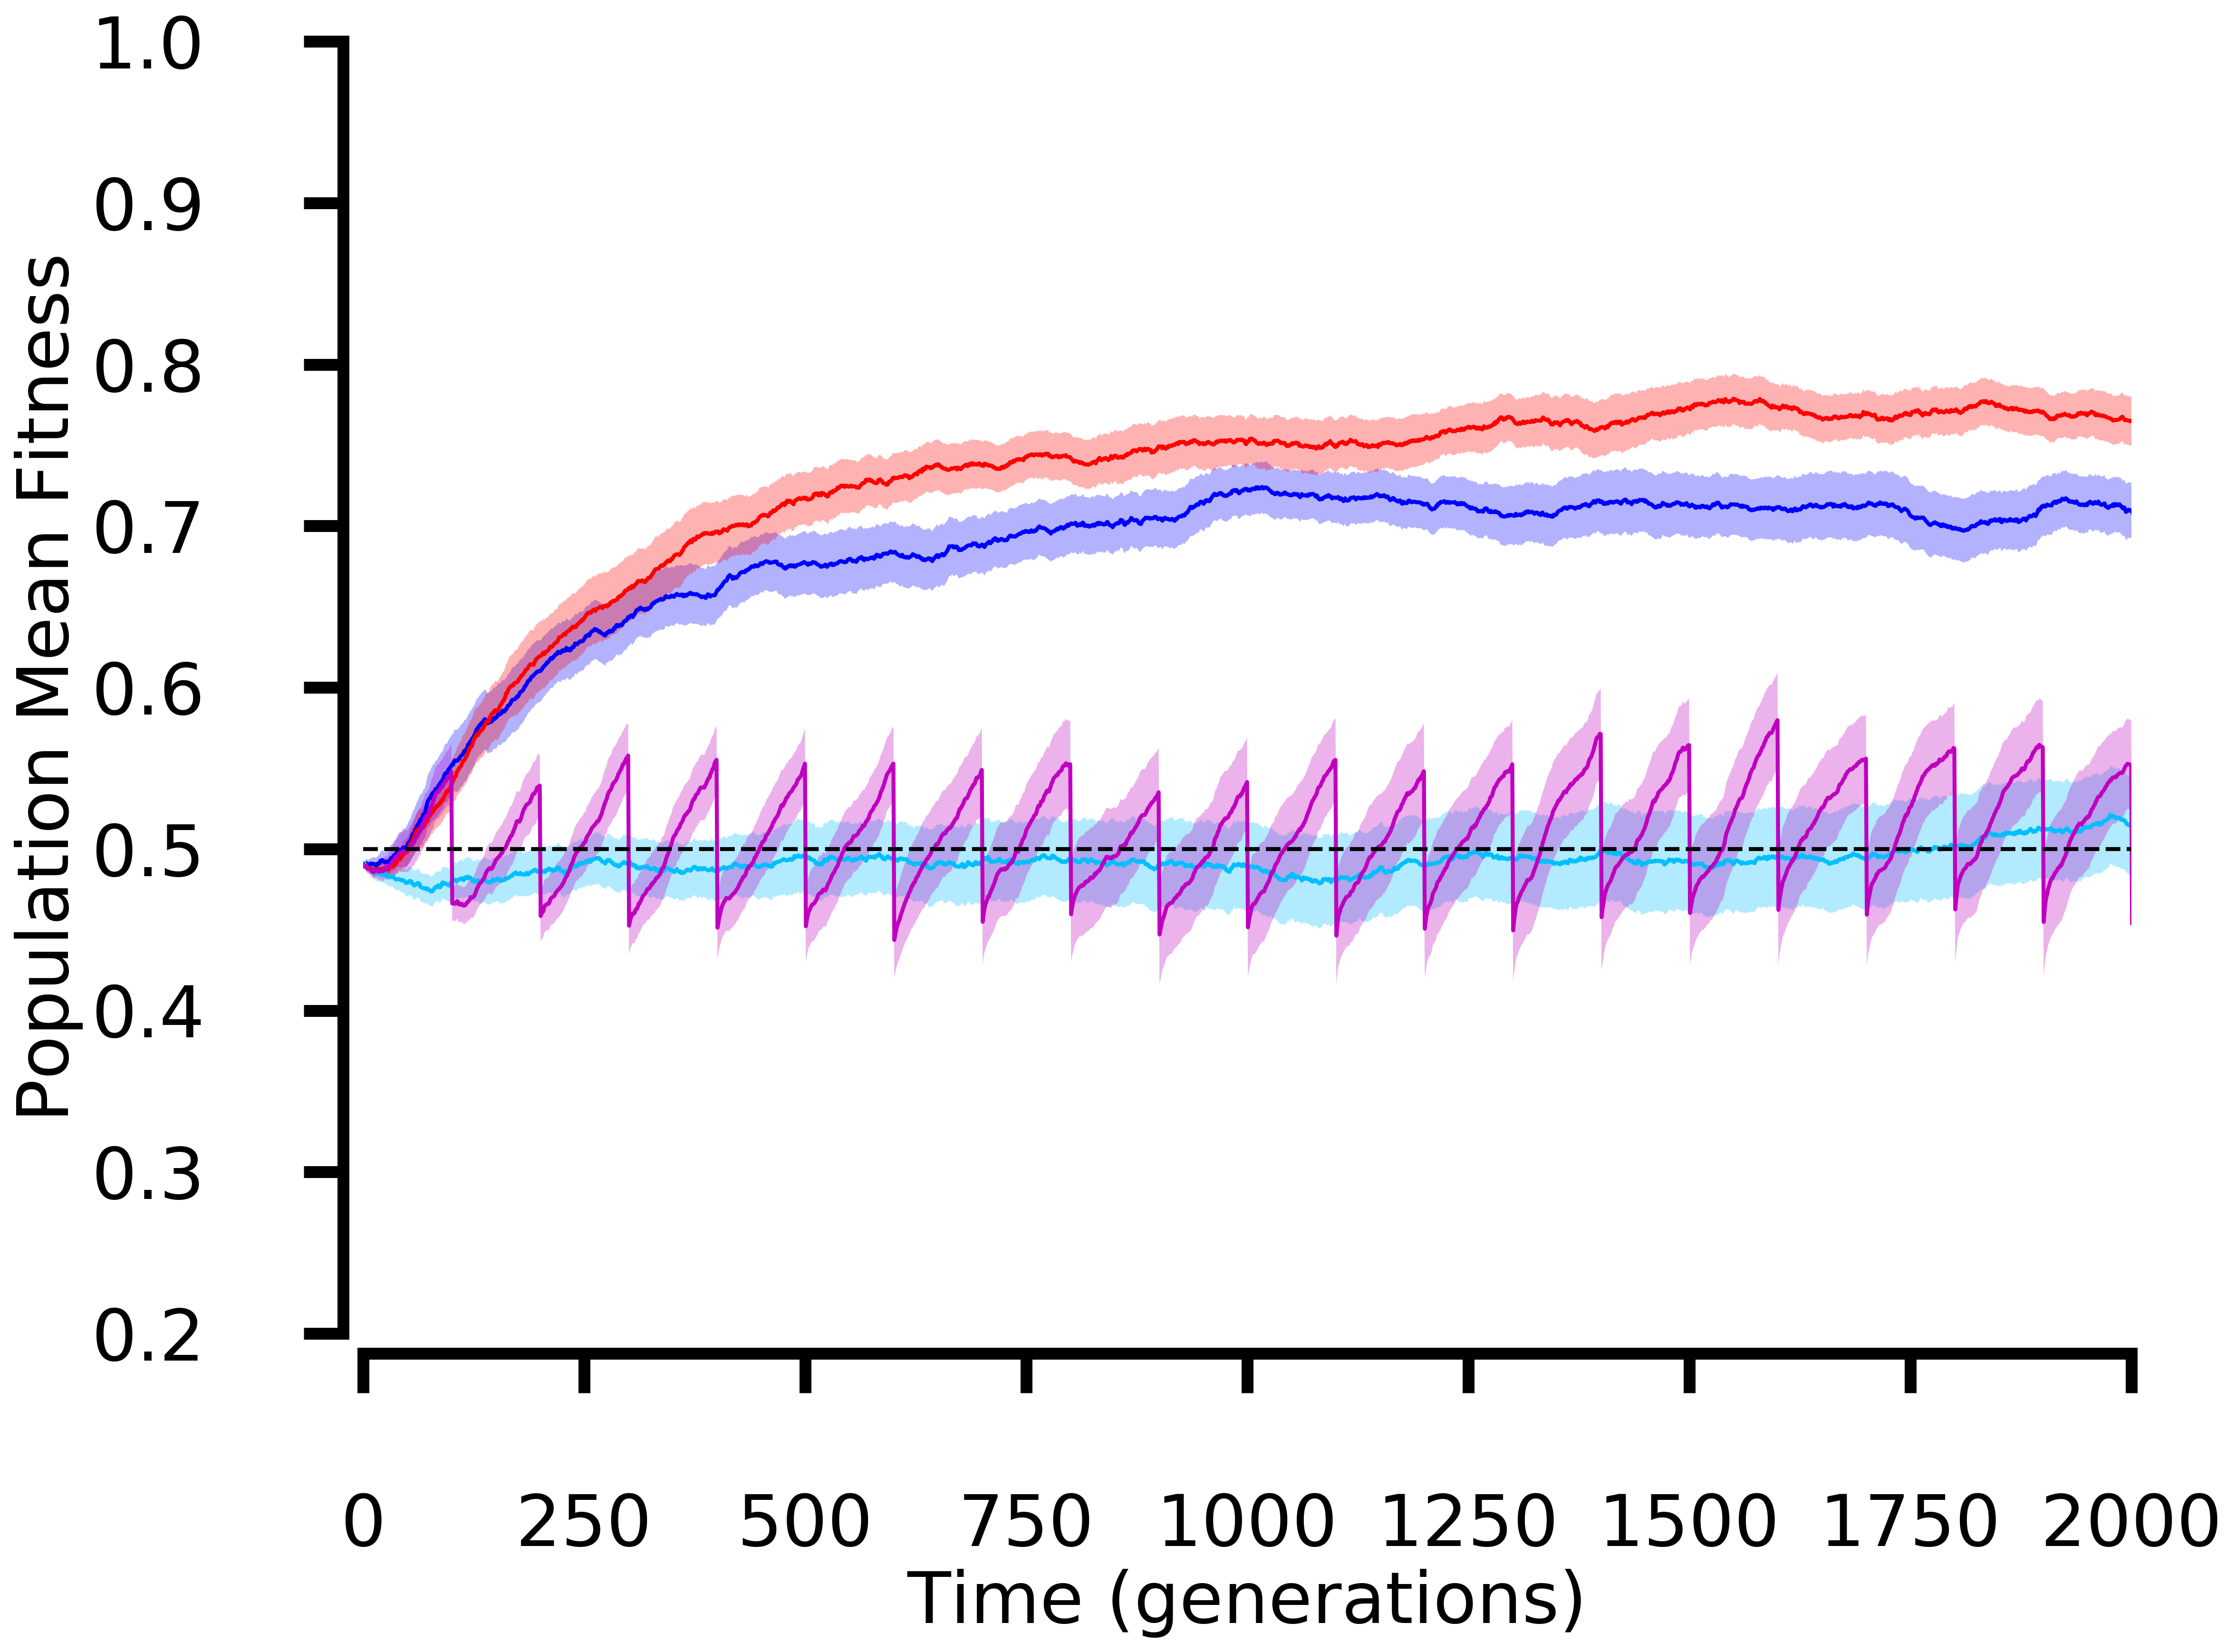

In [30]:
fig = plt.figure(figsize=(16, 12), dpi =300)
ax = fig.add_subplot(111)
publication_figure(ax)

ax.set_xlim(0,2000)

t = generation_list

a1 = amito_fit_mean[0]
error_a1 = list(1.98* np.array(amito_fit_std[0])/((100)**0.5))

a2 = mito_fit_mean[0]
error_a2 = list(1.98* np.array(mito_fit_std[0])/((100)**0.5))

a3 = rm_fit_mean[0]
error_a3 = list(1.98* np.array(rm_fit_std[0])/((100)**0.5))

a4 = rme_fit_mean[0]
error_a4 = list(1.98* np.array(rme_fit_std[0])/((100)**0.5))


ax.set_xlabel('Time (generations)', fontsize =36)
ax.set_ylabel('Population Mean Fitness', fontsize =36)


ax.plot(t,a1,'b', label = 'Amitosis',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.3, facecolor='b')

ax.plot(t,a2,'deepskyblue', label = 'Mitosis', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.3, facecolor='deepskyblue')


ax.plot(t,a3,'r', label = 'Sex Every Gen',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.3, facecolor='r')

ax.plot(t,a4,'m', label = 'Sex Every 100 Gens', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a4)- np.array(error_a4), np.array(a4)+ np.array(error_a4), alpha =0.3, facecolor='m')


  
plt.axhline(y=0.5, linewidth=2.0, color ='k',ls ='dashed')

ax.minorticks_off()

ax.set_ylim(0.2, 1)

#     plt.legend(loc='upper left', frameon=False, prop={'size':26})

### Ploidy = 128

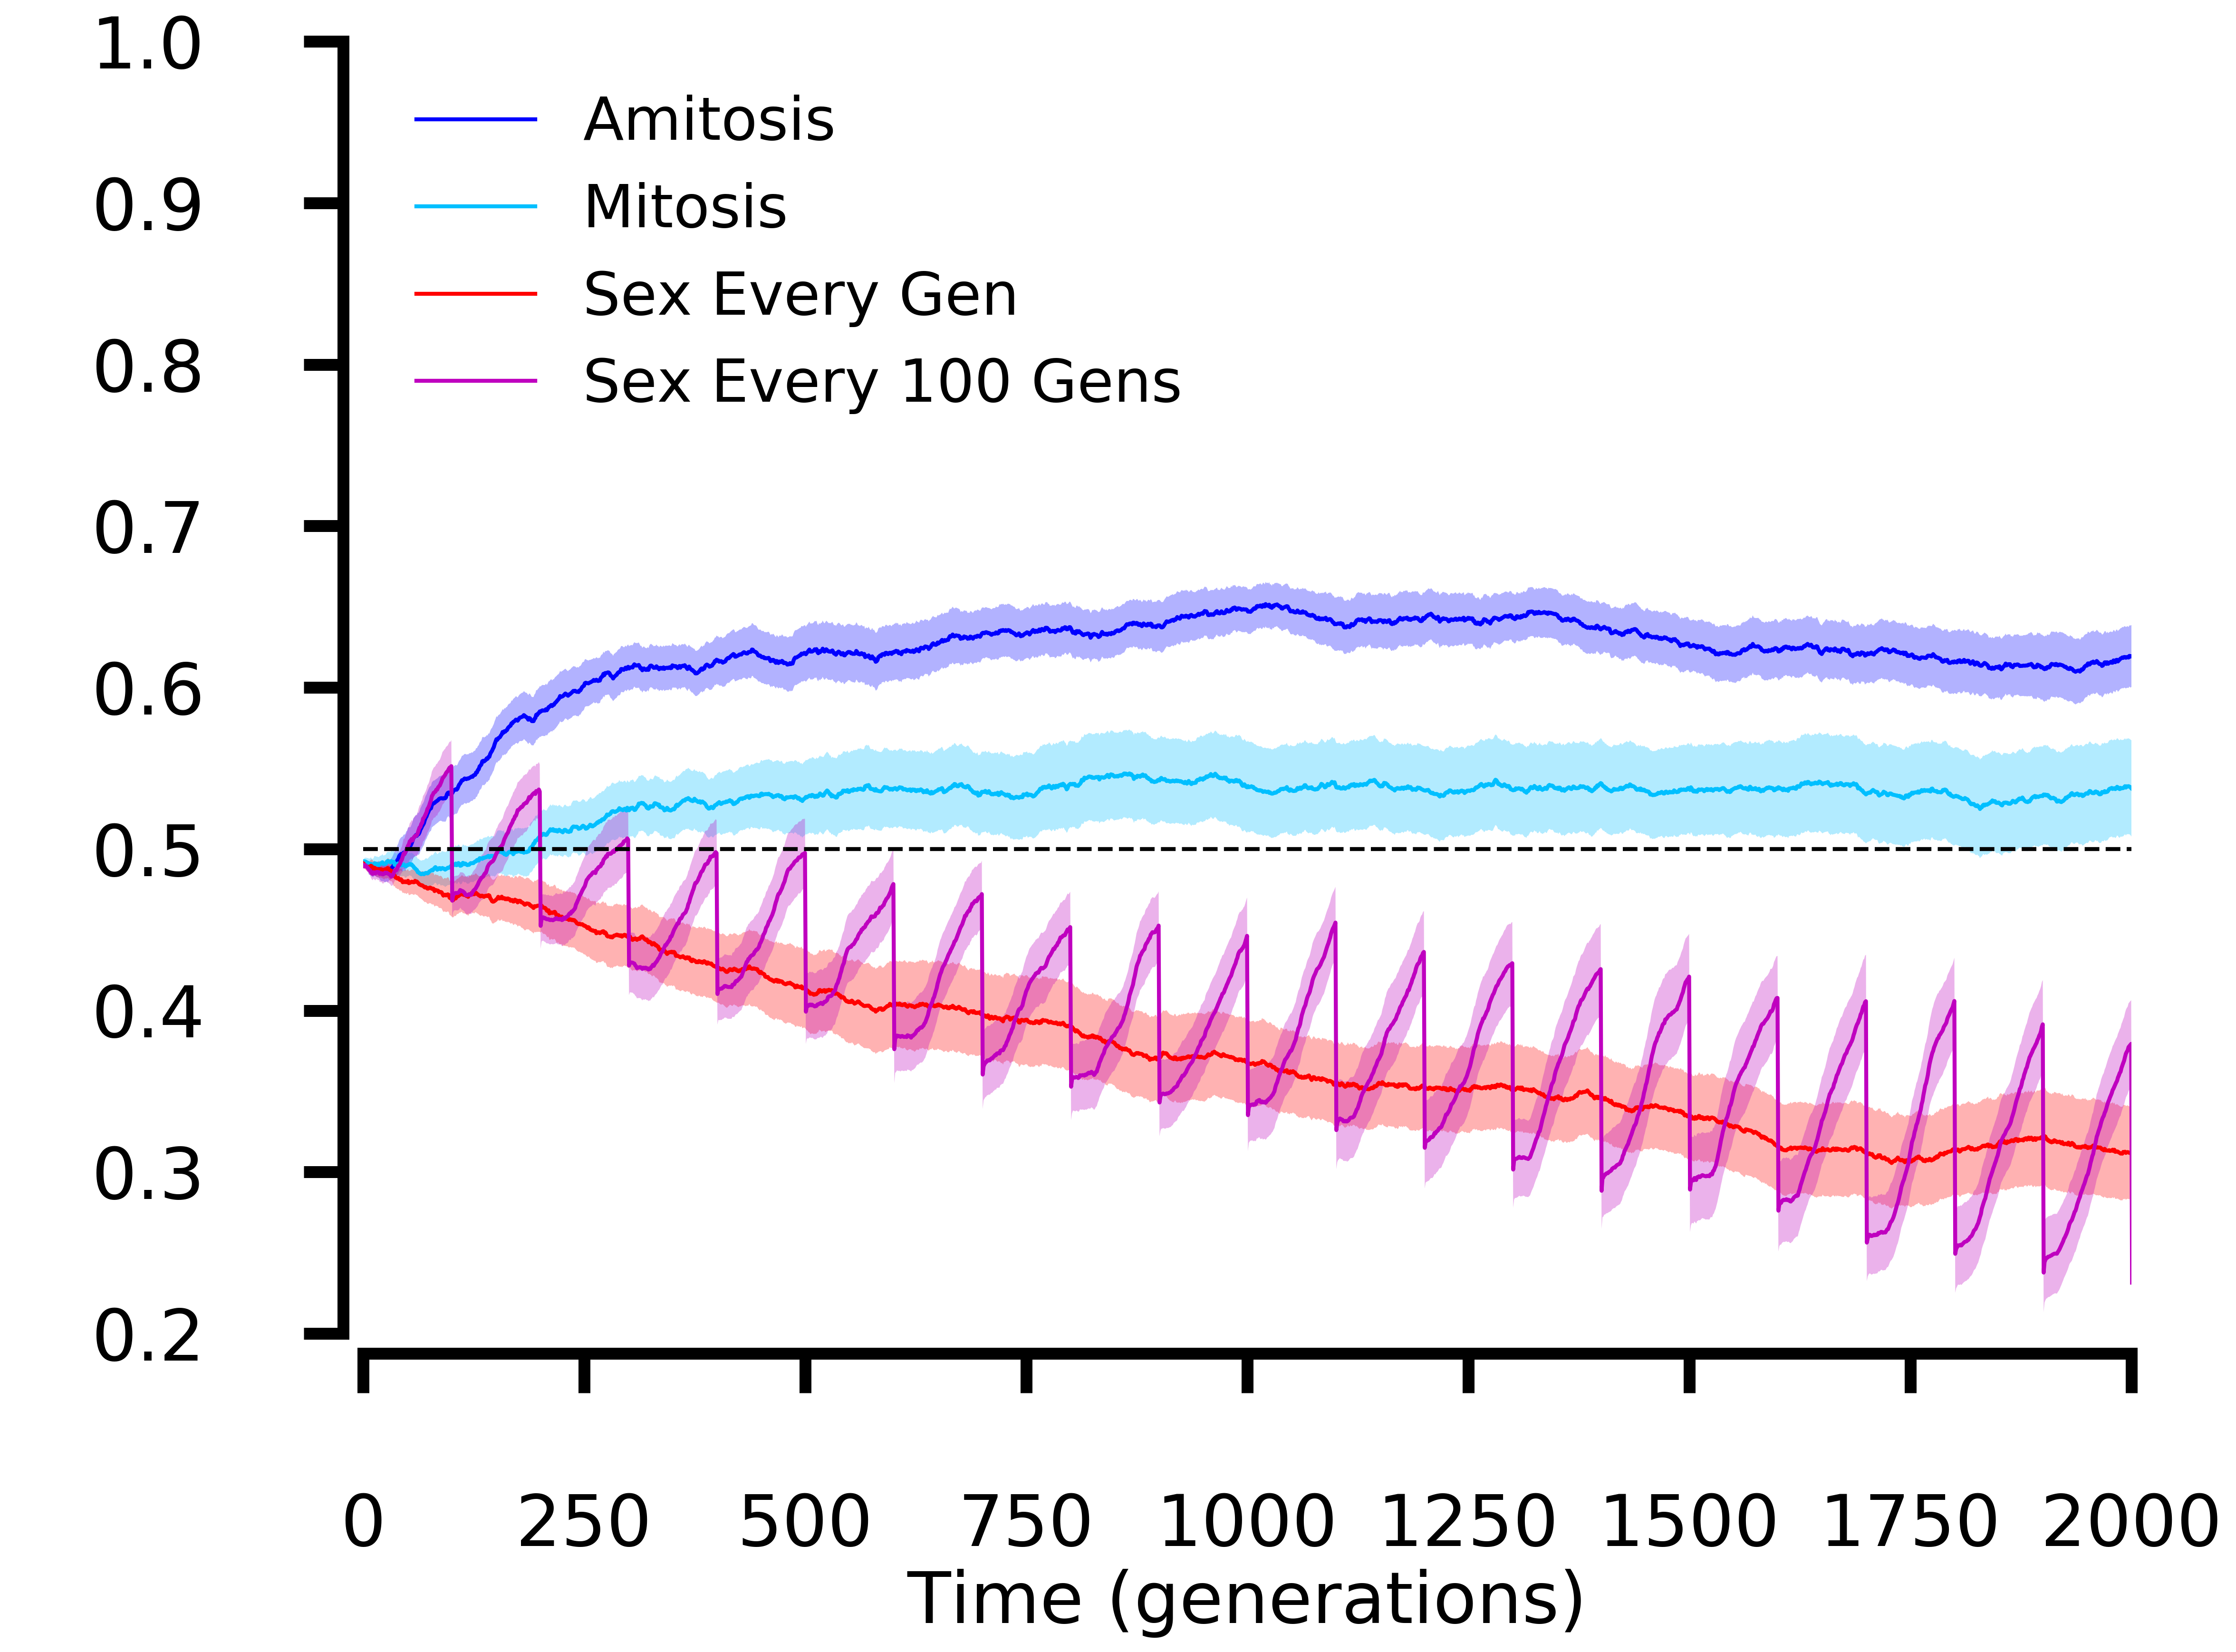

In [29]:
fig = plt.figure(figsize=(16, 12), dpi =300)
ax = fig.add_subplot(111)
publication_figure(ax)

ax.set_xlim(0,2000)

t = generation_list

a1 = amito_fit_mean[1]
error_a1 = list(1.98* np.array(amito_fit_std[1])/((100)**0.5))

a2 = mito_fit_mean[1]
error_a2 = list(1.98* np.array(mito_fit_std[1])/((100)**0.5))

a3 = rm_fit_mean[1]
error_a3 = list(1.98* np.array(rm_fit_std[1])/((100)**0.5))

a4 = rme_fit_mean[1]
error_a4 = list(1.98* np.array(rme_fit_std[1])/((100)**0.5))


ax.set_xlabel('Time (generations)', fontsize =36)
ax.set_ylabel('Population Mean Fitness', fontsize =36, color = 'white')


ax.plot(t,a1,'b', label = 'Amitosis',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.3, facecolor='b')

ax.plot(t,a2,'deepskyblue', label = 'Mitosis', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.3, facecolor='deepskyblue')


ax.plot(t,a3,'r', label = 'Sex Every Gen',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.3, facecolor='r')

ax.plot(t,a4,'m', label = 'Sex Every 100 Gens', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a4)- np.array(error_a4), np.array(a4)+ np.array(error_a4), alpha =0.3, facecolor='m')


  
plt.axhline(y=0.5, linewidth=2.0, color ='k',ls ='dashed')

ax.minorticks_off()

ax.set_ylim(0.2, 1)

plt.legend(loc='upper left', frameon=False, prop={'size':30})